# Bottleneck tutorial — `jupedsim-scenarios`

A guided tour of the library using the classic **bottleneck** scenario
(`examples/assets/bottleneck.zip`, exported from the
[Web-Based JuPedSim editor](https://github.com/PedestrianDynamics/Web-Based-Jupedsim)).

Five short steps, each adding one new capability:

1. **Load + run** a scenario, inspect the `ScenarioResult` object.
2. **Visualize** the trajectory with [pedpy](https://pedpy.readthedocs.io/).
3. **Sweep N** (agents) with seeds — stochasticity is real.
4. **Sweep model** at fixed N — swap models in one line.
5. **2D sweep**: model × bottleneck width — reproduce known physics.

Run top-to-bottom. Steps 3–5 take a few minutes each (tune `SEEDS_PER_COND`).

In [1]:
# Shared imports + constants
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jupedsim_scenarios import (
    load_scenario,
    run_scenario,
    run_sweep,
    run_sweep_from_factory,
)

ASSET = Path("assets/bottleneck.zip")
SEEDS_PER_COND = 2          # bump to 5+ for publication-quality variance
WORKERS = 4                 # parallel trial workers
plt.rcParams["figure.dpi"] = 110

## Step 1 — Load, run, inspect

The two API calls you'll use most: `load_scenario(path)` reads a zip
exported from the web editor, `run_scenario(scenario)` runs JuPedSim and
returns a `ScenarioResult`. Everything else in the tutorial builds on
this.

In [2]:
scenario = load_scenario(str(ASSET))
result = run_scenario(scenario, seed=42)

print(f"type:               {type(result).__name__}")
print(f"evacuation_time:    {result.evacuation_time:.2f} s")
print(f"agents_evacuated:   {result.agents_evacuated} / {result.total_agents}")
print(f"frame_rate:         {result.frame_rate} fps")
print(f"sqlite trajectory:  {result.sqlite_file}")
print()
print("metrics dict keys:", sorted(result.metrics.keys()))

Using fallback logic: No journeys defined
Processing with parameters: {'number': 50, 'radius': 0.2, 'v0': 1.3, 'flow_start_time': 0, 'flow_end_time': 10, 'percentage': None, 'distribution_mode': 'by_number', 'use_flow_spawning': False, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
Using default parameters: v0=1.3, radius=0.2, n_agents=50

Distribution jps-distributions_0: {'number': 50, 'radius': 0.2, 'v0': 1.3, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None}
Added 50 agents using fallback logic (immed

type:               ScenarioResult
evacuation_time:    52.16 s
agents_evacuated:   50 / 50
frame_rate:         10.0 fps
sqlite trajectory:  /tmp/tmp63g3ibra.sqlite

metrics dict keys: ['agents_evacuated', 'agents_remaining', 'all_evacuated', 'dt', 'evacuation_time', 'frame_rate', 'message', 'seed', 'status', 'success', 'total_agents', 'walkable_polygon']


## Step 2 — Visualize with pedpy

`result.sqlite_file` is a standard JuPedSim trajectory database, so it
plugs straight into pedpy's loaders and plotters.

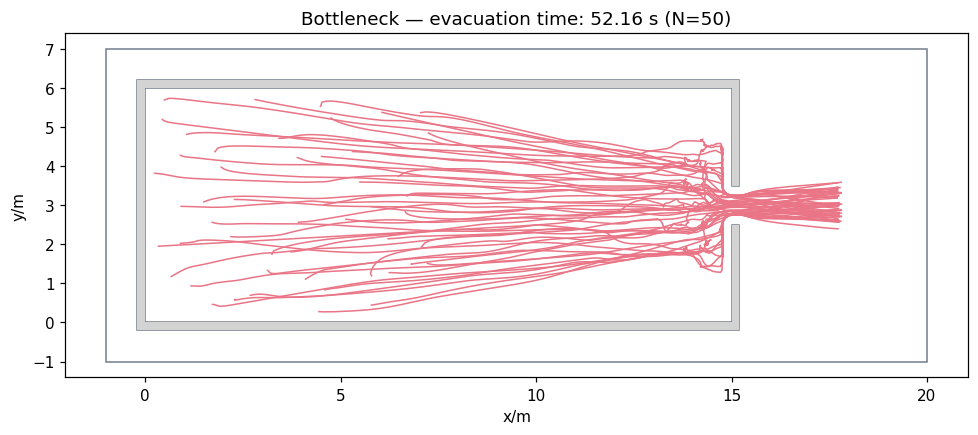

In [3]:
from pedpy import load_trajectory_from_jupedsim_sqlite, WalkableArea, plot_trajectories

traj = load_trajectory_from_jupedsim_sqlite(Path(result.sqlite_file))
walkable = WalkableArea(result.walkable_polygon)

fig, ax = plt.subplots(figsize=(9, 4))
plot_trajectories(traj=traj, walkable_area=walkable, axes=ax)
ax.set_title(f"Bottleneck — evacuation time: {result.evacuation_time:.2f} s "
             f"(N={result.total_agents})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

result.cleanup()   # delete the temp sqlite now that we're done with it

## Step 3 — Sweep N with seeds

`run_sweep` walks a cartesian product of axes and runs each combination
across all seeds. One axis here (`num_agents`), three values, two seeds
each = 6 trials. Same scenario, just mutated per-trial via `apply`.

Stochastic variance is real: even at fixed N, evac times scatter — that's
why we plot **mean ± std**, not a single number.

              mean         std  count
num_agents                           
30           34.49    2.983991      2
40           44.12    0.296985      2
50          177.03  173.905842      2


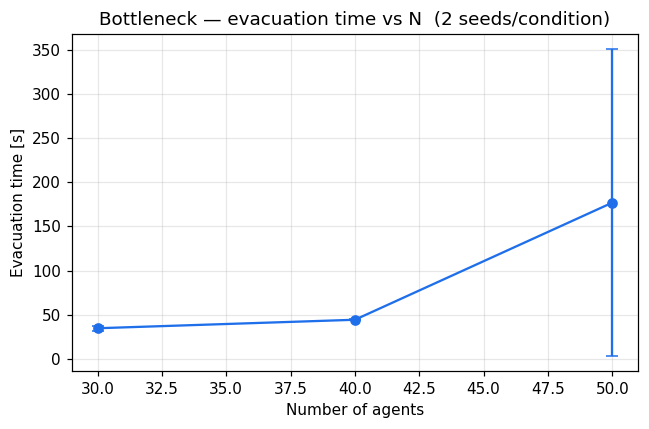

In [4]:
base = load_scenario(str(ASSET))

sweep_n = run_sweep(
    base,
    axes={"num_agents": [30, 40, 50]},
    apply={"num_agents": lambda s, n: s.set_agent_count("jps-distributions_0", n)},
    seeds=range(100, 100 + SEEDS_PER_COND),
    workers=WORKERS,
)

df_n = sweep_n.to_dataframe()
agg = df_n.groupby("num_agents")["evacuation_time"].agg(["mean", "std", "count"])
print(agg)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
            fmt="o-", capsize=4, color="#1f6feb")
ax.set_xlabel("Number of agents")
ax.set_ylabel("Evacuation time [s]")
ax.set_title(f"Bottleneck — evacuation time vs N  ({SEEDS_PER_COND} seeds/condition)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sweep_n.cleanup()

## Step 4 — Sweep models at N=50

Same `run_sweep`, different axis. `set_model_type` is a one-liner;
the rest of the scenario (geometry, distribution, exit) is untouched.

Macro outcomes (evacuation time) often agree across models — the
microscopic dynamics differ. We show both: a bar chart of evac times
and a side-by-side trajectory snapshot per model.

                              mean         std
model                                         
CollisionFreeSpeedModel     55.475    0.459619
CollisionFreeSpeedModelV3  172.365  180.503148
AnticipationVelocityModel  300.000    0.000000


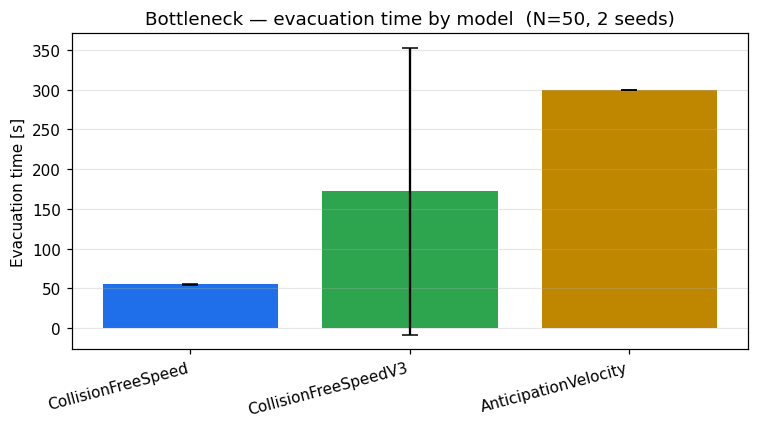

In [5]:
MODELS = [
    "CollisionFreeSpeedModel",
    "CollisionFreeSpeedModelV3",
    "AnticipationVelocityModel",
]

base = load_scenario(str(ASSET))

sweep_m = run_sweep(
    base,
    axes={"model": MODELS},
    apply={"model": lambda s, m: s.set_model_type(m)},
    seeds=range(200, 200 + SEEDS_PER_COND),
    workers=WORKERS,
)

df_m = sweep_m.to_dataframe()
agg_m = df_m.groupby("model")["evacuation_time"].agg(["mean", "std"]).reindex(MODELS)
print(agg_m)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(MODELS)), agg_m["mean"], yerr=agg_m["std"].fillna(0),
       capsize=5, color=["#1f6feb", "#2da44e", "#bf8700"])
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([m.replace("Model", "") for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Evacuation time [s]")
ax.set_title(f"Bottleneck — evacuation time by model  (N=50, {SEEDS_PER_COND} seeds)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

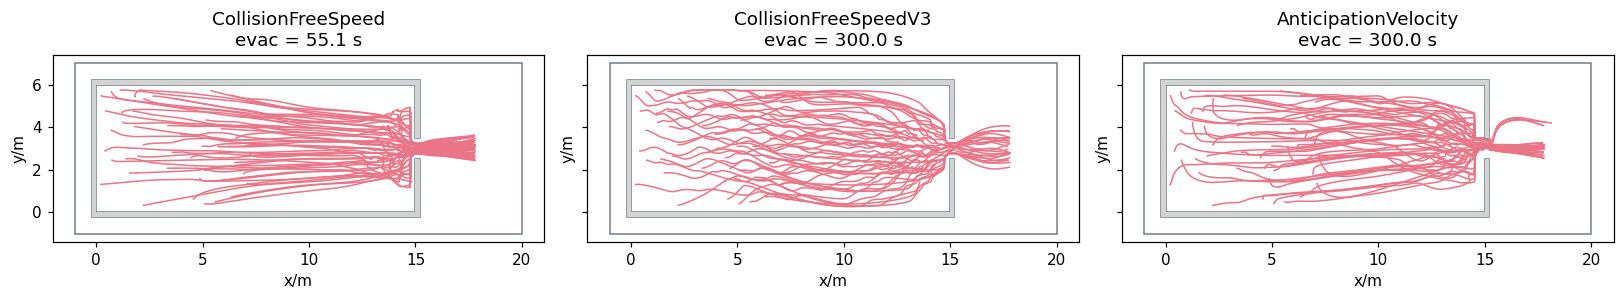

In [6]:
# Side-by-side trajectory snapshots — one representative seed per model
fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 4), sharey=True)
for ax, model in zip(axes, MODELS):
    trial = next(t for t in sweep_m.trials if t.axis_values["model"] == model)
    traj = load_trajectory_from_jupedsim_sqlite(Path(trial.result.sqlite_file))
    walkable = WalkableArea(trial.result.walkable_polygon)
    plot_trajectories(traj=traj, walkable_area=walkable, axes=ax)
    ax.set_title(f"{model.replace('Model', '')}\n"
                 f"evac = {trial.result.evacuation_time:.1f} s")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

sweep_m.cleanup()

## Step 5 — 2D sweep: model × bottleneck width

Here the geometry itself depends on the trial parameter (width), so we
switch to `run_sweep_from_factory`: each trial gets a freshly-built
scenario from our factory function.

The bottleneck opening in the default scenario sits between
`y = 2.5` and `y = 3.5` (width 1.0 m). We rewrite the WKT to vary it,
centred on `y = 3.0`.

We plot two curves per model:

- **Evacuation time vs width** — drops monotonically as width grows.
- **Specific flow** `J_s = N / (t · w)` **vs width** — should
  approach the empirical Kretz/Seyfried plateau of ~1.9 ped/(m·s).

In [7]:
WIDTHS = [0.8, 1.0, 1.2, 1.4, 1.6]
MODELS_2D = ["CollisionFreeSpeedModel", "AnticipationVelocityModel"]

def bottleneck_factory(params):
    s = load_scenario(str(ASSET))
    w = params["width"]
    y_lo, y_hi = 3.0 - w / 2, 3.0 + w / 2
    # Rewrite the inner ring of the walkable polygon so the bottleneck
    # opening (the gap between room and corridor at x in [15, 15.2])
    # has the requested width.
    s.walkable_area_wkt = (
        "POLYGON((20 7, 20 -1, -1 -1, -1 7, 20 7), "
        f"(15.2 {y_hi}, 15.2 6.199999999999999, -0.2 6.199999999999999, "
        f"-0.2 -0.2, 15.2 -0.2, 15.2 {y_lo}, 15 {y_lo}, "
        f"15 2.0000000000000002e-16, 0 0, 0 6, 15 6, 15 {y_hi}, 15.2 {y_hi}))"
    )
    s.set_model_type(params["model"])
    return s, None

trials = [{"model": m, "width": w} for m in MODELS_2D for w in WIDTHS]

sweep_2d = run_sweep_from_factory(
    bottleneck_factory,
    trials=trials,
    seeds=range(300, 300 + SEEDS_PER_COND),
    workers=WORKERS,
)

df = sweep_2d.to_dataframe()
df["specific_flow"] = df["total_agents"] / (df["evacuation_time"] * df["width"])
agg2 = (df.groupby(["model", "width"])
          [["evacuation_time", "specific_flow"]]
          .agg(["mean", "std"]))
print(agg2)

                                evacuation_time           specific_flow  \
                                           mean       std          mean   
model                     width                                           
AnticipationVelocityModel 0.8            300.00  0.000000      0.208333   
                          1.0            300.00  0.000000      0.166667   
                          1.2            300.00  0.000000      0.138889   
                          1.4            300.00  0.000000      0.119048   
                          1.6            300.00  0.000000      0.104167   
CollisionFreeSpeedModel   0.8             55.63  2.446589      1.124582   
                          1.0             55.63  2.446589      0.899666   
                          1.2             55.63  2.446589      0.749721   
                          1.4             55.63  2.446589      0.642618   
                          1.6             55.63  2.446589      0.562291   

                        

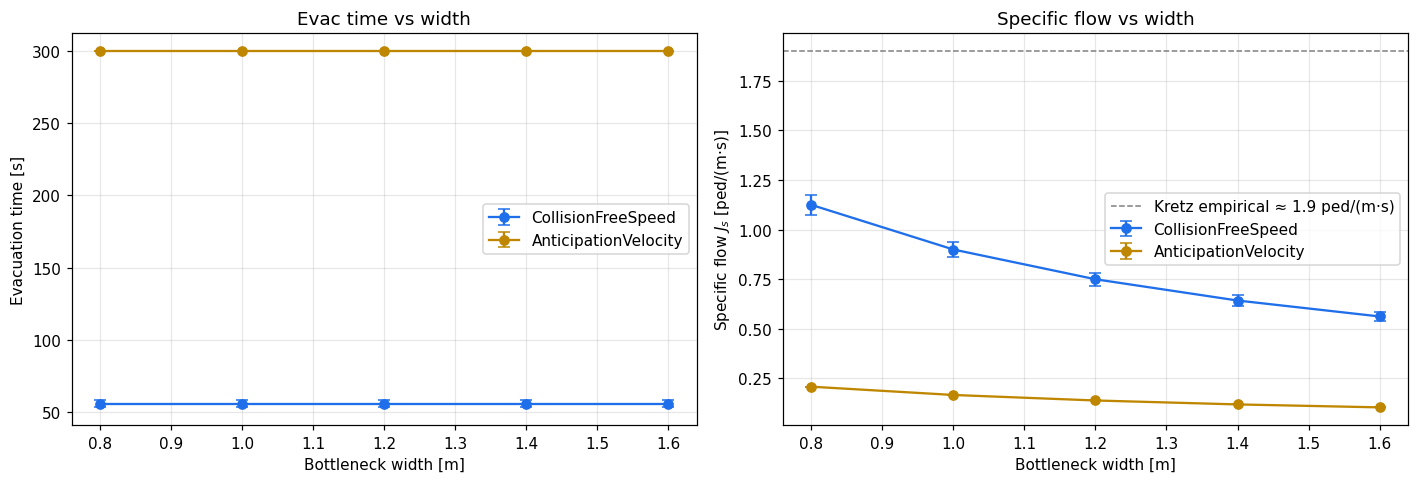

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"CollisionFreeSpeedModel": "#1f6feb",
          "AnticipationVelocityModel": "#bf8700"}

for model in MODELS_2D:
    sub = df[df.model == model].groupby("width")
    et = sub["evacuation_time"].agg(["mean", "std"])
    sf = sub["specific_flow"].agg(["mean", "std"])
    ax1.errorbar(et.index, et["mean"], yerr=et["std"].fillna(0),
                 fmt="o-", capsize=4, label=model.replace("Model", ""),
                 color=colors[model])
    ax2.errorbar(sf.index, sf["mean"], yerr=sf["std"].fillna(0),
                 fmt="o-", capsize=4, label=model.replace("Model", ""),
                 color=colors[model])

ax1.set_xlabel("Bottleneck width [m]")
ax1.set_ylabel("Evacuation time [s]")
ax1.set_title("Evac time vs width")
ax1.grid(alpha=0.3); ax1.legend()

ax2.axhline(1.9, color="gray", ls="--", lw=1,
            label="Kretz empirical ≈ 1.9 ped/(m·s)")
ax2.set_xlabel("Bottleneck width [m]")
ax2.set_ylabel("Specific flow $J_s$ [ped/(m·s)]")
ax2.set_title("Specific flow vs width")
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

sweep_2d.cleanup()

## Where to go from here

- Pick any `Scenario.set_*` mutator and add it as a sweep axis.
- For studies whose **geometry** depends on the parameter, use
  `run_sweep_from_factory` (as in step 5).
- Trial results expose `result.sqlite_file` and
  `result.trajectory_dataframe()` — both feed directly into pedpy for
  density, flow, Voronoi, and fundamental-diagram analysis.
- For long sweeps, persist `sweep.to_dataframe()` to CSV/parquet
  before calling `sweep.cleanup()`.